<a href="https://colab.research.google.com/github/Rakmik/NM/blob/main/%D0%9B%D0%A0%E2%84%964_%D0%97%D0%B0%D0%B3%D0%B8%D0%BD%D0%B0%D0%B9%D0%BA%D0%BE_%D0%9F%D0%B0%D0%B2%D0%BB%D0%BE_%D0%A4%D0%86%D0%A2_2_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

!. Знайти матрицю С = 𝐴𝐵 − 𝐵𝐴

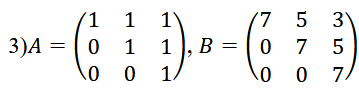

In [3]:
import numpy as np

In [4]:
A = np.array([[1, 1, 1],
              [0, 1, 1],
              [0, 0, 1]])

In [5]:
B = np.array([[7, 5, 3],
              [0, 7, 5],
              [0, 0, 7]])

In [6]:
AB = np.dot(A, B)
BA = np.dot(B, A)

C = AB - BA

In [7]:
print("Матриця A:")
print(A)

print("\nМатриця B:")
print(B)

print("\nМатриця C = AB - BA:")
print(C)

Матриця A:
[[1 1 1]
 [0 1 1]
 [0 0 1]]

Матриця B:
[[7 5 3]
 [0 7 5]
 [0 0 7]]

Матриця C = AB - BA:
[[0 0 0]
 [0 0 0]
 [0 0 0]]


2. Піднести матриці до степеня

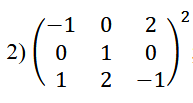

In [8]:
A = np.array([
    [-1, 0, 2],
    [ 0, 1, 0],
    [ 1, 2, -1]
])

In [13]:
result = np.linalg.matrix_power(A, 2)

print("Результат:")
print(result)

Результат:
[[  2   7  35]
 [-23   7 -16]
 [ -9   4   0]]


3. Знайти добуток матриць

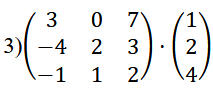

In [10]:
A = np.array([
    [ 3, 0, 7],
    [-4, 2, 3],
    [-1, 1, 2]
])

In [11]:
B = np.array([
    [1],
    [2],
    [4]
])

In [12]:
result = np.dot(A, B)

print("Результат множення:")
print(result)

Результат множення:
[[31]
 [12]
 [ 9]]


4. Обчислити визначники

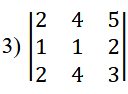

In [14]:
A = np.array([
    [2, 4, 5],
    [1, 1, 2],
    [2, 4, 3]
])

In [15]:
det_A = np.linalg.det(A)

print(f"Визначник матриці: {round(det_A)}")

Визначник матриці: 4


5. Обчислити визначники

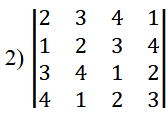

In [19]:
a = np.array([
    [2, 3, 4, 1],
    [1, 2, 3, 4],
    [3, 4, 1, 2],
    [4, 1, 2, 3]
])

In [20]:
a_det = np.linalg.det(a)

print("Визначник матриці:")
print(int(np.round(a_det)))

Визначник матриці:
-160


6. Знайти обернену матрицю до матриць

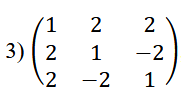

In [21]:
a = np.array([
    [1,  2,  2],
    [2,  1, -2],
    [2, -2,  1]
])

In [23]:
a_inv = np.linalg.inv(a)

check = np.dot(a, a_inv)

print("Обернена матриця:")
print(a_inv)

print("\nПеревірка:")
print(np.round(check))

Обернена матриця:
[[ 0.11111111  0.22222222  0.22222222]
 [ 0.22222222  0.11111111 -0.22222222]
 [ 0.22222222 -0.22222222  0.11111111]]

Перевірка:
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [ 0.  0.  1.]]


7. Визначити ранг матриці

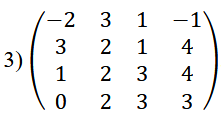

In [24]:
a = np.array([
    [-2, 3, 1, -1],
    [ 3, 2, 1,  4],
    [ 1, 2, 3,  4],
    [ 0, 2, 3,  3]
])

In [25]:
rank = np.linalg.matrix_rank(a)

print("Ранг матриці:")
print(rank)

Ранг матриці:
3


8. Розв’язати систему лінійних рівнянь методом Крамера, матричним
методом (тобто обчислити обернену матрицю) і м. Гауса. Потім
зробити перевірку за допомогою solve() пакету linalg

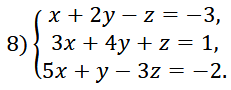

In [30]:
A = np.array([
    [1, 2, -1],
    [3, 4, 1],
    [5, 1, -3]
], dtype=float)

B = np.array([-3, 1, -2], dtype=float)

In [42]:
def solve_kramer(A, B):
    det_A = np.linalg.det(A)
    if abs(det_A) < 1e-9:
        return "Система не має єдиного розв'язку (det=0)"

    results = []
    for i in range(len(B)):
        A_i = A.copy()
        A_i[:, i] = B
        results.append(np.linalg.det(A_i) / det_A)
    return np.array(results)

In [43]:
def solve_matrix_method(A, B):
    try:
        A_inv = np.linalg.inv(A)

        return A_inv.dot(B)

    except np.linalg.LinAlgError:
        return "Матриця вироджена, оберненої не існує"

In [44]:
def solve_gauss(A, B):
    # Об'єднуємо в розширену матрицю
    Ab = np.hstack([A, B.reshape(-1, 1)])
    n = len(B)

    # Прямий хід
    for i in range(n):
        # Пошук головного елемента (для стабільності)
        max_row = np.argmax(abs(Ab[i:, i])) + i
        Ab[[i, max_row]] = Ab[[max_row, i]]

        for j in range(i + 1, n):
            ratio = Ab[j, i] / Ab[i, i]
            Ab[j] -= ratio * Ab[i]

    # Зворотний хід
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Ab[i, -1] - np.dot(Ab[i, i+1:n], x[i+1:n])) / Ab[i, i]
    return x

In [46]:
print("1. Метод Крамера")
res_kramer = solve_kramer(A, B)
print(f"x = {res_kramer[0]:.2f}, y = {res_kramer[1]:.2f}, z = {res_kramer[2]:.2f}\n")

print("2. Матричний метод")
res_matrix = solve_matrix_method(A, B)
print(f"x = {res_matrix[0]:.2f}, y = {res_matrix[1]:.2f}, z = {res_matrix[2]:.2f}\n")

print("3. Метод Гаусса")
res_gauss = solve_gauss(A, B)
print(f"x = {res_gauss[0]:.2f}, y = {res_gauss[1]:.2f}, z = {res_gauss[2]:.2f}\n")

print("Перевірка через linalg.solve()")
res_final = np.linalg.solve(A, B)
print(f"Результат: x={res_final[0]}, y={res_final[1]}, z={res_final[2]}")

1. Метод Крамера
x = 1.00, y = -1.00, z = 2.00

2. Матричний метод
x = 1.00, y = -1.00, z = 2.00

3. Метод Гаусса
x = 1.00, y = -1.00, z = 2.00

Перевірка через linalg.solve()
Результат: x=1.0, y=-1.0000000000000002, z=2.0


9. Розв’язати 1 завдання з наведених нижче.

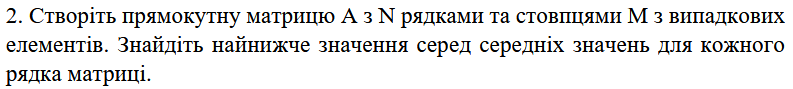

In [35]:
N = 5
M = 4

In [39]:
matrix_a = np.random.randint(0, 10, size=(N, M))

print("Матриця A:")
print(matrix_a)

Матриця A:
[[8 0 2 8]
 [0 0 6 6]
 [9 5 3 2]
 [6 6 6 5]
 [0 5 7 6]]


In [40]:
row_means = np.mean(matrix_a, axis=1)

print("\nСередні значення для кожного рядка:")
print(row_means)


Середні значення для кожного рядка:
[4.5  3.   4.75 5.75 4.5 ]


In [41]:
min_mean = np.min(row_means)

print(f"\nНайнижче середнє значення: {min_mean:.2f}")


Найнижче середнє значення: 3.00
